The MNIST dataset is a classic dataset for image classification, containing 70,000 grayscale images of handwritten digits (0-9).

Importing Necessary Libraries

In [94]:
#SREELAKSHMI V
#MCA AI & DS
#KH.EN.P2MCA25158

#DATASET - CIFAR10

In [95]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10 as cf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


In [96]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = cf.load_data()

In [97]:
x_train.shape

(50000, 32, 32, 3)

In [98]:
x_test.shape

(10000, 32, 32, 3)

In [99]:
print(y_test)

[[3]
 [8]
 [8]
 ...
 [5]
 [1]
 [7]]


In [100]:
#Displaying Sample Images from the MNIST Dataset
# Select random indices for displaying images
import numpy as np
indices = np.random.randint(0, x_train.shape[0], size=16)

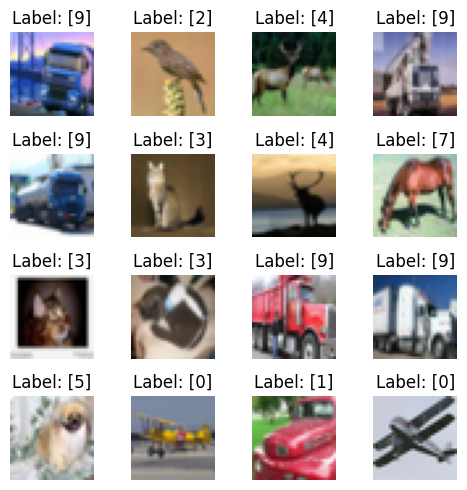

In [101]:
# Create a figure and subplots
fig, axes = plt.subplots(4, 4, figsize=(5, 5))

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, ax in enumerate(axes):
    image = x_train[indices[i]]
    label = y_train[indices[i]]
    ax.imshow(image)
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [102]:
# Reshape data for CNN input
img_rows, img_cols = 32, 32
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 3)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 3)


**Purpose of Reshaping**
The goal of this reshaping is to transform the data into a 4-dimensional array, which is the standard format for image data in CNNs. The dimensions represent:

Number of samples: The total number of images in the dataset.

Image height: The height of each image in pixels.

Image width: The width of each image in pixels.

Number of channels: The number of color channels in the image.

Example:If you have 60000 images of size 28x28 pixels and they are grayscale, the original shape of x_train would be (60000, 28, 28). After reshaping, it becomes (60000, 28, 28, 1).

**Why is this necessary?**

CNNs are designed to process data in this format. By reshaping the data, we ensure that it's compatible with the CNN's input layer.

**Code description:**
x_train: This is the variable holding the training data.

reshape(): This is a NumPy function to change the shape of an array without changing its data.

x_train.shape[0]: This part extracts the number of samples in the training data.

img_rows: The number of rows in each image.

img_cols: The number of columns in each image.

1: This indicates the number of channels in the image. For grayscale images, it's 1, while for color images, it would be 3 (RGB).

In [103]:
x_train.shape
#x_test.shape

(50000, 32, 32, 3)

In [104]:
# Normalize pixel values to be between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

In [105]:
# Convert class vectors to binary class matrices

num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


In [106]:
print(y_test)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


In [107]:
# Create a CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3), padding='same', strides=1))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

In [114]:
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

**Categorical cross-entropy** is a loss function used in machine learning for multi-class classification problems. It measures the difference between the true class distribution (the label) and the predicted probability distribution.

**How it works:**

Softmax Activation: The model outputs a vector of values, one for each possible class. These values are passed through a softmax function to convert them into probabilities that sum up to 1.

Cross-Entropy Calculation: The cross-entropy loss is calculated by comparing the predicted probability distribution with the true class distribution (one-hot encoded). The goal is to minimize this loss, which means the model should learn to predict probabilities closer to the true class.

**Adam: An Optimization Algorithm**

Adam is a popular optimization algorithm used in machine learning, especially for training neural networks. It combines the best aspects of two other optimization algorithms: AdaGrad and RMSprop.

How Adam Works:

Adaptive Learning Rates: Adam adapts the learning rate for each parameter individually, which helps accelerate training and improve performance.
Momentum: It incorporates momentum to help the algorithm escape local minima.
Bias Correction: To counteract the initial bias of the estimates, Adam includes bias correction mechanisms.

In [115]:
# Train the model
history=model.fit(x_train, y_train, batch_size=128, epochs=10, verbose=1, validation_data=(x_test, y_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - accuracy: 0.7434 - loss: 0.7321 - val_accuracy: 0.6436 - val_loss: 1.0518
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 108ms/step - accuracy: 0.7612 - loss: 0.6916 - val_accuracy: 0.6454 - val_loss: 1.0521
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.7727 - loss: 0.6624 - val_accuracy: 0.6582 - val_loss: 1.0111
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - accuracy: 0.7821 - loss: 0.6344 - val_accuracy: 0.6612 - val_loss: 1.0158
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.7917 - loss: 0.6074 - val_accuracy: 0.6502 - val_loss: 1.0507
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.8009 - loss: 0.5805 - val_accuracy: 0.6583 - val_loss: 1.0405
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.8125 - loss: 0.5474 - val_accuracy: 0.6533 - val_loss: 1.0844
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.8207 - loss: 0

In [113]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,152,672 (12.03 MB)

 Trainable params: 1,050,890 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,101,782 (8.02 MB)

In [117]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6642 - loss: 1.0799
Test accuracy: 0.6608999967575073


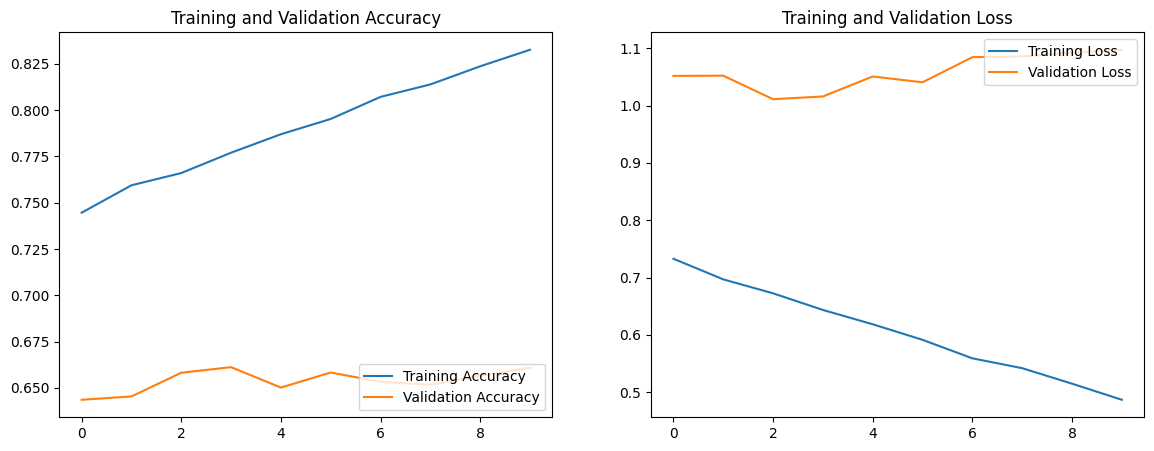

In [120]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./foo.png')
plt.show()